<a href="https://colab.research.google.com/github/mehakknasirr/neurofive-ml-track/blob/main/Handling_Imbalanced_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Class Distribution ===
Class
0    9754
1     246
Name: count, dtype: int64


/tmp/ipykernel_600/4164209748.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=['#1f77b4', '#d62728'])


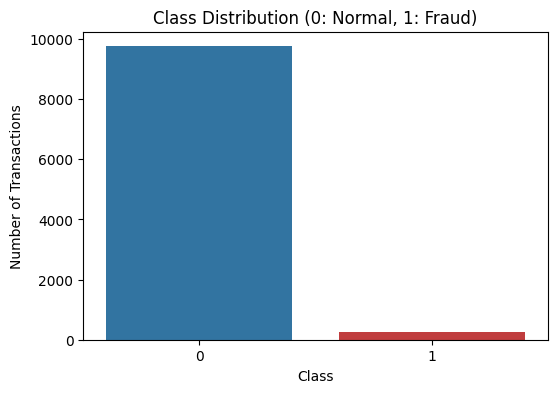


=== Performance Comparison ===

--- Before SMOTE (Imbalanced) ---
Precision: 1.0000
Recall:    0.0204
F1-Score:  0.0400

--- After SMOTE (Balanced) ---
Precision: 0.0662
Recall:    0.7551
F1-Score:  0.1217


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE

# 1. Generate Synthetic Imbalanced Fraud Dataset (98% Normal, 2% Fraud)
X, y = make_classification(n_samples=10000, n_features=10, n_informative=5,
                           n_redundant=2, weights=[0.98, 0.02], random_state=42)

df = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(10)])
df['Class'] = y # 0: Normal, 1: Fraud

# 2. Check Class Balance & Visualize
class_counts = df['Class'].value_counts()
print("=== Class Distribution ===")
print(class_counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette=['#1f77b4', '#d62728'])
plt.title("Class Distribution (0: Normal, 1: Fraud)")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.show()

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Train Base Model (Before SMOTE)
model_imb = LogisticRegression(max_iter=1000)
model_imb.fit(X_train, y_train)
y_pred_imb = model_imb.predict(X_test)

# 5. Apply SMOTE to Address Imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 6. Retrain Model (After SMOTE)
model_bal = LogisticRegression(max_iter=1000)
model_bal.fit(X_train_smote, y_train_smote)
y_pred_bal = model_bal.predict(X_test)

# 7. Compare Performance Metrics
def print_metrics(name, y_true, y_pred):
    print(f"\n--- {name} ---")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")

print("\n=== Performance Comparison ===")
print_metrics("Before SMOTE (Imbalanced)", y_test, y_pred_imb)
print_metrics("After SMOTE (Balanced)", y_test, y_pred_bal)


### 📉 Why "Accuracy" is a Misleading Metric for Imbalanced Data

In highly imbalanced datasets like Credit Card Fraud Detection (e.g., 99% normal transactions and 1% fraud), a "dumb" model that simply predicts every transaction as "Normal" will achieve 99% accuracy.

However, this model is completely useless because it catches 0% of the actual fraud cases (Recall = 0). This creates a false illusion of strong performance. Therefore, we must rely on metrics like **Precision** (out of all predicted frauds, how many were real?), **Recall** (out of all real frauds, how many did we catch?), and the **F1-Score** (harmonic mean of Precision and Recall) to truly evaluate the model's effectiveness on the minority class.
